# Dataset generation

| Var             | Range       | Unit | Description                             |
|-----------------|-------------|------|-----------------------------------------|
| $\eta_{PV}$     | 5-20        |      | panel efficiency                        |
| $\eta_{UGC}$    | 80-95       |      | PMU efficiency                          |
| $\eta_{B}$      | 80-90       |      | battery efficiency                      |
| $\eta_{STC}$    | 19-22       | %    | nominal efficiency of energy conversion |
| $A_{\text{PV}}$ |             | m²   | photovoltaic panel surface              |
| $P_{PV}$        |             | W    | panel power output                      |
| G(h)            |             | W/m² | hourly solar irradiance                 |
| Pn              |             | W    | power demand                            |
| Ppmu            |             | W    | PMU power                               |
| Pb              |             | W    | battery power                           |
| $\gamma$        | -0.29, -0.5 | %/ºC | temperature coefficient                 |

In [123]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## Panel generation

In [124]:
# load panels from panels.csv
panels_raw = pd.read_csv('panel_areas.csv')
panels_raw['Apv(m2)'] = (panels_raw['width_cm'].astype(float) / 100) * (panels_raw['height_cm'].astype(float) / 100)
Apv = sorted(panels_raw['Apv(m2)'].unique())
print(f"Loaded {len(panels_raw):,} panels, unique areas: {len(Apv)}")
display(panels_raw.head(10))

Loaded 120 panels, unique areas: 89


,width_cm,height_cm,Apv(m2)
0,1,1,0.0001
1,1,2,0.0002
2,1,3,0.0003
3,1,4,0.0004
4,1,5,0.0005
5,1,6,0.0006
6,1,7,0.0007
7,1,8,0.0008
8,1,9,0.0009
9,1,10,0.0010


In [125]:
# generate panels

eta_stc = [x / 10 for x in range(190, 221, 5)]
panels = list(itertools.product(Apv, eta_stc))
panels_df = pd.DataFrame(panels, columns=['Apv(m2)', 'eta_stc(%)'])
panels_df['Panel_ID'] = range(0, len(panels_df))
panels_df = panels_df[['Panel_ID', 'Apv(m2)', 'eta_stc(%)']]

print(f"# possible panels: {len(Apv)} × {len(eta_stc)} = {len(panels_df):,}")
print("First 10:")
display(panels_df.head(10))


# possible panels: 89 × 7 = 623
First 10:


,Panel_ID,Apv(m2),eta_stc(%)
0,0,0.0001,19.0
1,1,0.0001,19.5
2,2,0.0001,20.0
3,3,0.0001,20.5
4,4,0.0001,21.0
5,5,0.0001,21.5
6,6,0.0001,22.0
7,7,0.0002,19.0
8,8,0.0002,19.5
9,9,0.0002,20.0


## Irradiance data (Gh_data)

Load irradiance data from CSV file with hourly data for the whole year.

In [126]:
# Column name constants (use these everywhere to refer to CSV columns)
COL_RAW_DATETIME = 'Date-hour'  # original datetime
COL_MONTH = 'Month'
COL_DAY = 'Day'
COL_HOUR = 'Hour'
COL_G = 'G(h)'
COL_TEMP = 'Temperature'

In [127]:
# Columns: Month, Day, Hour, G(h), Temperature
orig_Gh_data = pd.read_csv('irradiance.csv', usecols=[0,1,2,3,4,5])

# Rename columns to standard constants
# CSV header has: Date-hour, Month, Day, Hour, G(h), Temperature
orig_Gh_data.columns = [COL_RAW_DATETIME, COL_MONTH, COL_DAY, COL_HOUR, COL_G, COL_TEMP]

print("📊 IRRADIANCE Gh_data")
print(f"Total records: {len(orig_Gh_data):,}")
print(f"Available columns: {list(orig_Gh_data.columns)}")
print(f"Dataset shape: {orig_Gh_data.shape}")
print(f"Months: {orig_Gh_data[COL_MONTH].min()} - {orig_Gh_data[COL_MONTH].max()}")
print(f"Days: {orig_Gh_data[COL_DAY].min()} - {orig_Gh_data[COL_DAY].max()}")

# Show basic statistics for G(h)
gh_column = COL_G  # use constant
print(f"\n🌞 IRRADIANCE STATISTICS {gh_column}:")
print(f"Min: {orig_Gh_data[gh_column].min():.2f} W/m²")
print(f"Max: {orig_Gh_data[gh_column].max():.2f} W/m²")
print(f"Mean: {orig_Gh_data[gh_column].mean():.2f} W/m²")
print(f"Records with {gh_column} > 0: {(orig_Gh_data[gh_column] > 0).sum():,}")

print(f"\n🔍 FIRST 5 ROWS:")
display(orig_Gh_data.head())

print(f"\n📊 COLUMN INFO:")
display(orig_Gh_data.info())


📊 IRRADIANCE Gh_data
Total records: 8,760
Available columns: ['Date-hour', 'Month', 'Day', 'Hour', 'G(h)', 'Temperature']
Dataset shape: (8760, 6)
Months: 1 - 12
Days: 1 - 31

🌞 IRRADIANCE STATISTICS G(h):
Min: 0.00 W/m²
Max: 1045.00 W/m²
Mean: 184.93 W/m²
Records with G(h) > 0: 4,400

🔍 FIRST 5 ROWS:


,Date-hour,Month,Day,Hour,G(h),Temperature
0,20210101-0000,1,1,0,0,5.47
1,20210101-0100,1,1,1,0,4.94
2,20210101-0200,1,1,2,0,4.40
3,20210101-0300,1,1,3,0,3.87
4,20210101-0400,1,1,4,0,3.34



📊 COLUMN INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date-hour    8760 non-null   object 
 1   Month        8760 non-null   int64  
 2   Day          8760 non-null   int64  
 3   Hour         8760 non-null   int64  
 4   G(h)         8760 non-null   int64  
 5   Temperature  8760 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 410.8+ KB


None

In [128]:
# --- Detect and remove nighttime (all-zero) hours while preserving original `orig_Gh_data` ---
# Determine which 'Hour' values have G(h) == 0 for every record (full-year) and create `data` (filtered) without those rows.

gh_col = COL_G  # G(h) column name
hour_col = COL_HOUR  # Hour column name

# Work on a copy to avoid mutating orig_Gh_data in-place
Gh_data = orig_Gh_data.copy()

# Ensure Hour is integer
Gh_data[hour_col] = Gh_data[hour_col].astype(int)

# For each hour (0-23), check if all G(h) values are zero across the dataset
hour_all_zero = Gh_data.groupby(hour_col)[gh_col].apply(lambda x: (x == 0).all())
zero_hours = sorted([int(h) for h, all_zero in hour_all_zero.items() if all_zero])

# Merge consecutive hours into ranges for clearer reporting
zero_ranges = []
start = prev = zero_hours[0]
for h in zero_hours[1:]:
    if h == prev + 1:
        prev = h
        continue
    else:
        zero_ranges.append((start, prev))
        start = prev = h
zero_ranges.append((start, prev))

print(f"Detected zero-only hours: {zero_hours}")
print(f"Merged zero-hour ranges: {zero_ranges}")

# Create final filtered `data`
Gh_data = Gh_data[~Gh_data[hour_col].isin(zero_hours)].reset_index(drop=True)
removed_rows = len(orig_Gh_data) - len(Gh_data)
print(f"Original rows: {len(orig_Gh_data):,}, removed: {removed_rows:,}  , remaining: {len(Gh_data):,})")


Detected zero-only hours: [0, 1, 2, 3, 4, 20, 21, 22, 23]
Merged zero-hour ranges: [(0, 4), (20, 23)]
Original rows: 8,760, removed: 3,285  , remaining: 5,475)


## Power calculation

In [129]:
def panel_power(Gh, Apv, nstc):
    """
    Calculate panel power output considering temperature effects.

    Parameters:
    - Gh: Irradiance (W/m²)
    - Apv: Panel area (m²)
    - nstc: Panel efficiency at standard test conditions (decimal)

    Returns:
    - Power output (W)
    """

    return Gh * Apv * nstc

def panel_power_with_temp(Gh, Apv, nstc, Tmod, temp_coeff=-0.004):
    """
    Calculate panel power output considering temperature effects.

    Parameters:
    - Gh: Irradiance (W/m²)
    - Apv: Panel area (m²)
    - nstc: Panel efficiency at standard test conditions (decimal)
    - Tmod: panel temperature (°C)
    - temp_coeff: Temperature coefficient (default -0.004 per °C)

    Returns:
    - Power output (W)
    """

    # Adjust efficiency based on temperature
    nPV = nstc * (1 + temp_coeff * (Tmod - 25))  # equation (3)
    return Gh * Apv * nPV  # equation (2)

In [130]:
def get_irradiance(day, hour):
    if not (1 <= day <= 31 and 0 <= hour <= 23):
        return None

    row = Gh_data[(Gh_data[COL_DAY] == day) & (Gh_data[COL_HOUR] == hour)]
    if row.empty:
        return None

    return row.iloc[0][COL_G]

In [131]:
# Calculate the power of each panel for each irradiance value

panel_powers = []
for idx, panel in panels_df.iterrows():
    Apv = panel['Apv(m2)']
    nstc = panel['eta_stc(%)'] / 100  # convert to fraction

    powers = []
    for Gh, Tmod in zip(Gh_data[COL_G], Gh_data[COL_TEMP]):
        powers.append(panel_power_with_temp(Gh, Apv, nstc, Tmod))
    panel_powers.append(powers)

panel_powers = pd.DataFrame(panel_powers)
panel_powers.index = panels_df['Panel_ID']
panel_powers.columns = [f"Gh_{i}" for i in range(len(panel_powers.columns))]

print("Power calculated for all panels and all irradiance values.")
display(panel_powers.head())

Power calculated for all panels and all irradiance values.


,Gh_0,Gh_1,Gh_2,Gh_3,Gh_4,Gh_5,Gh_6,Gh_7,Gh_8,Gh_9,...,Gh_5465,Gh_5466,Gh_5467,Gh_5468,Gh_5469,Gh_5470,Gh_5471,Gh_5472,Gh_5473,Gh_5474
Panel_ID,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.001265,0.004598,0.006974,0.009201,0.001006,0.009446,0.000061,...,0.005829,0.000081,0.009162,0.000966,0.007510,0.004465,0.001512,0.0,0.0,0.0
1,0.0,0.0,0.0,0.001298,0.004719,0.007158,0.009443,0.001032,0.009695,0.000063,...,0.005983,0.000083,0.009403,0.000991,0.007708,0.004583,0.001552,0.0,0.0,0.0
2,0.0,0.0,0.0,0.001331,0.004840,0.007341,0.009686,0.001059,0.009943,0.000065,...,0.006136,0.000085,0.009644,0.001017,0.007905,0.004700,0.001592,0.0,0.0,0.0
3,0.0,0.0,0.0,0.001365,0.004962,0.007525,0.009928,0.001085,0.010192,0.000066,...,0.006289,0.000088,0.009886,0.001042,0.008103,0.004818,0.001631,0.0,0.0,0.0
4,0.0,0.0,0.0,0.001398,0.005083,0.007708,0.010170,0.001112,0.010440,0.000068,...,0.006443,0.000090,0.010127,0.001067,0.008301,0.004935,0.001671,0.0,0.0,0.0


In [132]:
# Calculate the total energy generated by each panel throughout the year (Wh)
# The energy per hour is equal to the power per hour (Wh)
total_panel_energy = panel_powers.sum(axis=1)
panels_with_energy = panels_df.copy()
panels_with_energy['Total_energy_Wh'] = total_panel_energy
print("Total energy generated by each panel throughout the year (Wh):")
display(panels_with_energy[['Panel_ID', 'Apv(m2)', 'eta_stc(%)', 'Total_energy_Wh']].head())

Total energy generated by each panel throughout the year (Wh):


,Panel_ID,Apv(m2),eta_stc(%),Total_energy_Wh
0,0,0.0001,19.0,31.222484
1,1,0.0001,19.5,32.044128
2,2,0.0001,20.0,32.865773
3,3,0.0001,20.5,33.687417
4,4,0.0001,21.0,34.509061


In [133]:
# Calculate daily energy generated by each panel (Wh/day)
num_days = len(panel_powers.columns) // 24
day_labels = [f"day_{(i//24+1):03d}" for i in range(len(panel_powers.columns))]
panel_daily_energy = panel_powers.copy()
panel_daily_energy.columns = day_labels
panel_daily_energy = panel_daily_energy.T.groupby(level=0).sum().T
panel_daily_energy.index = panels_df['Panel_ID']
print("Daily energy generated by each panel (Wh/day):")
display(panel_daily_energy.head())

Daily energy generated by each panel (Wh/day):


,day_001,day_002,day_003,day_004,day_005,day_006,day_007,day_008,day_009,day_010,...,day_220,day_221,day_222,day_223,day_224,day_225,day_226,day_227,day_228,day_229
Panel_ID,,,,,,,,,,,,,,,,,,,,,
0,0.074259,0.065969,0.059948,0.052977,0.023452,0.061559,0.072157,0.114547,0.064925,0.111967,...,0.047826,0.057902,0.063935,0.096057,0.029145,0.053118,0.059544,0.073355,0.081687,0.0
1,0.076213,0.067705,0.061526,0.054371,0.024069,0.063179,0.074056,0.117562,0.066633,0.114914,...,0.049085,0.059426,0.065617,0.098585,0.029912,0.054516,0.061111,0.075285,0.083836,0.0
2,0.078167,0.069441,0.063103,0.055766,0.024686,0.064799,0.075954,0.120576,0.068342,0.117860,...,0.050343,0.060950,0.067299,0.101112,0.030679,0.055914,0.062678,0.077216,0.085986,0.0
3,0.080121,0.071177,0.064681,0.057160,0.025304,0.066419,0.077853,0.123590,0.070050,0.120807,...,0.051602,0.062474,0.068982,0.103640,0.031446,0.057311,0.064245,0.079146,0.088136,0.0
4,0.082075,0.072913,0.066258,0.058554,0.025921,0.068039,0.079752,0.126605,0.071759,0.123753,...,0.052860,0.063997,0.070664,0.106168,0.032213,0.058709,0.065812,0.081076,0.090285,0.0


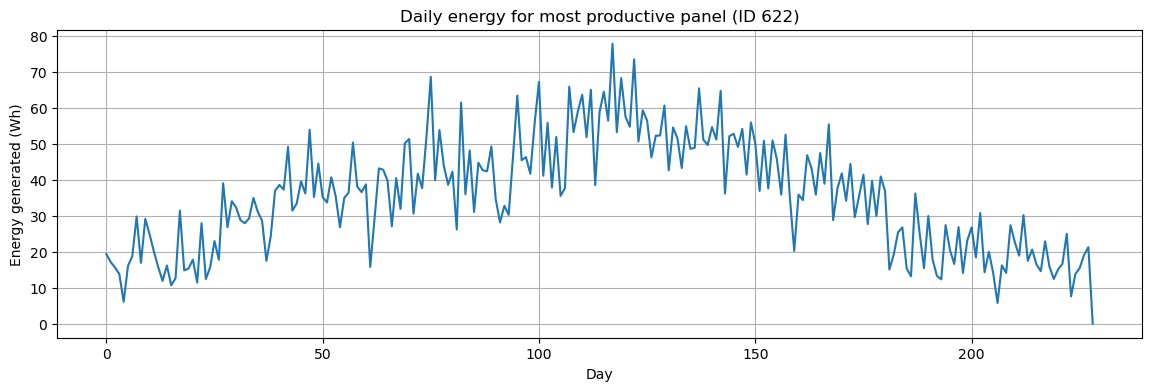

In [134]:
# Plot daily energy for the most productive panel
most_productive_panel_id = panel_daily_energy.sum(axis=1).idxmax()
energy_per_day = panel_daily_energy.loc[most_productive_panel_id]
plt.figure(figsize=(14,4))
plt.plot(energy_per_day.values)
plt.title(f"Daily energy for most productive panel (ID {most_productive_panel_id})")
plt.xlabel("Day")
plt.ylabel("Energy generated (Wh)")
plt.grid(True)
plt.show()

## Battery

In [135]:
def battery_required_energy(Tbat, Pn, nc):
    """
    Calculate the required battery energy capacity.
    Parameters:
    - Tbat: Autonomy time (hours)
    - Pn: Mean nominal power (W)
    - nc: Battery efficiency (decimal)
    """
    assert 0 < nc <= 1, "Battery efficiency must be between 0 and 1"
    return (Tbat * Pn) / nc


def battery_autonomy(Qbat, Pn, nc):
    """
    Calculate the battery autonomy time.
    Parameters:
    - Ebat: Battery energy capacity (Wh)
    - Pn: Mean nominal power (W)
    - nc: Battery efficiency (decimal)
    """
    assert 0 < nc <= 1, "Battery efficiency must be between 0 and 1"
    return (Qbat * nc) / Pn

In [136]:
# Example battery

Qbat = 10  # capacity (Ah)
Vbat = 12  # voltage (V)
Iload = 0.5   # mean load current (A)
nc = 0.9  # battery efficiency (decimal)

Tbat = battery_autonomy(Qbat, Iload * Vbat, nc)
print(f"Battery autonomy: {Tbat:.2f} hours")

Battery autonomy: 1.50 hours
